In [58]:
import opendatasets as od
import os
import random
import string
import re
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.data import Dataset
from tensorflow.keras import layers,Sequential
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns

# Download text dataset

In [2]:
od.download("https://www.kaggle.com/datasets/mohidabdulrehman/vs-sentiment-analysis")

Skipping, found downloaded files in ".\vs-sentiment-analysis" (use force=True to force download)


# Load dataset

In [3]:
os.listdir("./vs-sentiment-analysis/")

['Beginner_Reviews_dataset.csv']

In [4]:
df_sentiment = pd.read_csv('./vs-sentiment-analysis/Beginner_Reviews_dataset.csv')

# Data study

In [5]:
df_sentiment.head()

,Unnamed: 0,sentence,label
0,0,Wow... Loved this place.,1
1,1,Crust is not good.,0
2,2,Not tasty and the texture was just nasty.,0
3,3,Stopped by during the late May bank holiday of...,1
4,4,The selection on the menu was great and so wer...,1


In [6]:
df_sentiment.tail()

,Unnamed: 0,sentence,label
995,995,I think food should have flavor and texture an...,0
996,996,Appetite instantly gone.,0
997,997,Overall I was not impressed and would not go b...,0
998,998,"The whole experience was underwhelming, and I ...",0
999,999,"Then, as if I hadn't wasted enough of my life ...",0


In [7]:
# Visualize random samples
random_index = random.randint(0, len(df_sentiment)-10)
for row in df_sentiment[['sentence','label']][random_index:random_index+10].itertuples():
    _,sentence,label = row
    print(f'\nLabel:{label}\nText:{sentence}')


Label:1
Text:An extensive menu provides lots of options for breakfast.

Label:1
Text:I always order from the vegetarian menu during dinner, which has a wide array of options to choose from.

Label:0
Text:I have watched their prices inflate, portions get smaller and management attitudes grow rapidly!

Label:1
Text:Wonderful lil tapas and the ambience made me feel all warm and fuzzy inside.

Label:1
Text:I got to enjoy the seafood salad, with a fabulous vinegrette.

Label:1
Text:The wontons were thin, not thick and chewy, almost melt in your mouth.

Label:1
Text:Level 5 spicy was perfect, where spice didn't over-whelm the soup.

Label:1
Text:We were sat right on time and our server from the get go was FANTASTIC!

Label:0
Text:Main thing I didn't enjoy is that the crowd is of older crowd, around mid 30s and up.

Label:1
Text:When I'm on this side of town, this will definitely be a spot I'll hit up again!


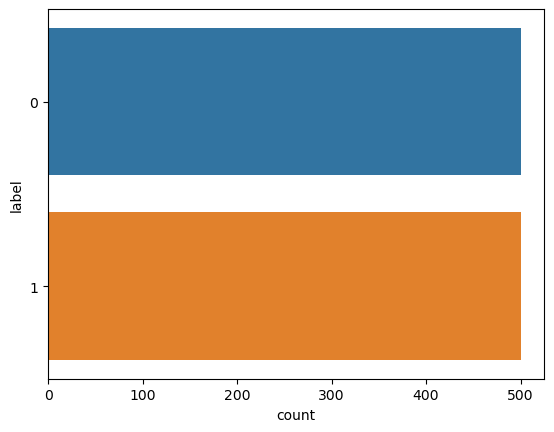

In [8]:
# check class distribution
sns.countplot(y = df_sentiment.label);

In [9]:
#Check for null values
df_sentiment.isna().sum()

Unnamed: 0    0
sentence      0
label         0
dtype: int64

In [10]:
#Visualize some DataFrame information
df_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1000 non-null   int64 
 1   sentence    1000 non-null   object
 2   label       1000 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 23.6+ KB


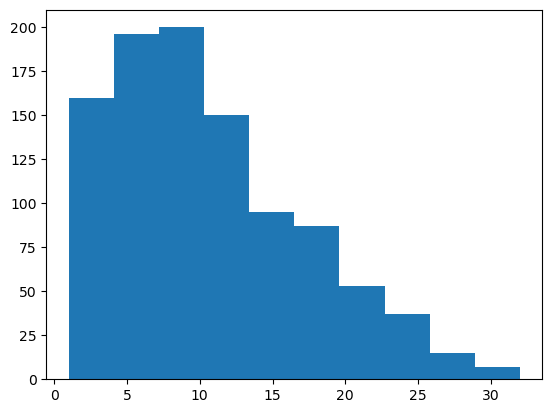

In [11]:
# visualize sentences lengths
sentences_lens = [len(i.split()) for i in df_sentiment.sentence]
plt.hist(sentences_lens);

In [12]:
 #How long of a sentence length covers 95% of the examples
output_length = int(np.percentile(sentences_lens, 95))
output_length

23

# Removing unnecessary punctuation, and possible HTML tags or URLs

In [13]:
def preprocess_text(text):
    '''
    Args:
        text->sequence of words
    Returns:
        text without unnecessary punctuation, html tags and urls and in lowercase
    '''
    clean_text = ''.join([word.lower() for word in text if word not in string.punctuation])
    clean_text = re.sub('https?://\S+|www\.\S+','',clean_text)
    return clean_text

In [14]:
# Test with one sample
random_sample = random.choice(df_sentiment.sentence)
print(f'Original text:{random_sample}\nPreprocessed text:{preprocess_text(random_sample)}')

Original text:I think this restaurant suffers from not trying hard enough.
Preprocessed text:i think this restaurant suffers from not trying hard enough


In [15]:
#apply function to all sentences
df_sentiment.sentence = df_sentiment.sentence.apply(lambda x: preprocess_text(x))

In [16]:
df_sentiment

,Unnamed: 0,sentence,label
0,0,wow loved this place,1
1,1,crust is not good,0
2,2,not tasty and the texture was just nasty,0
3,3,stopped by during the late may bank holiday of...,1
4,4,the selection on the menu was great and so wer...,1
...,...,...,...
995,995,i think food should have flavor and texture an...,0
996,996,appetite instantly gone,0
997,997,overall i was not impressed and would not go back,0
998,998,the whole experience was underwhelming and i t...,0


## Splitting data into training ,validation and test datasets

In [17]:
train_sentences, test_sentences, train_labels, test_labels = train_test_split(df_sentiment.sentence.to_numpy(),
                                                                              df_sentiment.label.to_numpy(),
                                                                              test_size=0.2,
                                                                              shuffle=True)

In [18]:
val_sentences, test_sentences, val_labels, test_labels = train_test_split(test_sentences,
                                                                          test_labels,
                                                                          test_size=0.5)

In [19]:
# visualize how many samples in each dataset
len(train_sentences),len(val_sentences),len(test_sentences)

(800, 100, 100)

## Creation of Text vectorizer layer to map text

In [20]:
output_length

23

In [21]:
MAX_VOCAB = 10000
text_vectorizer = layers.TextVectorization(max_tokens=MAX_VOCAB,
                                           output_sequence_length=output_length,
                                           pad_to_max_tokens=True)

In [22]:
#Adapt text vectorizer to train sentences
text_vectorizer.adapt(train_sentences)

In [23]:
# Visualize vocabulary
vocab = text_vectorizer.get_vocabulary()
print(f"5 Most common words:{vocab[:5]}")
print(f"5 Least common words:{vocab[-5:]}")

5 Most common words:['', '[UNK]', 'the', 'and', 'i']
5 Least common words:['2007', '1979', '17', '15lb', '15']


In [24]:
#Vectorizing one random sample to check if layer is working correctly
random_sentence=random.choice(train_sentences)
print(f"""
Original text:\n{random_sentence}\n
Original text length: {len(random_sentence.split())}\n
Vectorized text:\n{text_vectorizer([random_sentence])}\n
Vectorized text length: {text_vectorizer([random_sentence]).shape[1]}
""")


Original text:
i can assure you that you wont be disappointed

Original text length: 9

Vectorized text:
[[  4 104 741  33  24  33  71  27  85   0   0   0   0   0   0   0   0   0
    0   0   0   0   0]]

Vectorized text length: 23



## Creation of an embedding layer

In [25]:
embedding = layers.Embedding(input_dim=MAX_VOCAB,
                             output_dim=128,
                             mask_zero=True,
                             input_length=output_length)

In [26]:
#embedding one random sample after vectorization to check if layer is working correctly
random_sentence=random.choice(train_sentences)
print(f"""
Original text:\n{random_sentence}\n
Original text length: {len(random_sentence.split())}\n
Embed text:\n{embedding(text_vectorizer([random_sentence]))}\n
Embed text shape: {embedding(text_vectorizer([random_sentence])).shape}
""")


Original text:
i go to far too many places and ive never seen any restaurant that serves a 1 egg breakfast especially for 400

Original text length: 22

Embed text:
[[[ 0.0229631  -0.01881241 -0.04536134 ... -0.03713133 -0.02562171
    0.0153184 ]
  [ 0.0014267   0.01297542  0.01607715 ...  0.01012275  0.02771895
    0.00147204]
  [-0.02553521  0.04725223  0.04730889 ...  0.02098301 -0.03980863
   -0.03412999]
  ...
  [ 0.01261777  0.01389748 -0.03864114 ... -0.03622859  0.01040106
   -0.03954188]
  [ 0.04542596  0.01862041 -0.0266637  ...  0.04630126  0.01509266
    0.01345317]
  [ 0.01496326  0.0494823   0.01234005 ...  0.04858461  0.02800785
    0.00970327]]]

Embed text shape: (1, 23, 128)



### Creating datasets to load data as fast as possible even if the dataset is relatively small

In [27]:
# Creation of datasets, batch data and prefetch
train_dataset = Dataset.from_tensor_slices((train_sentences, train_labels)).batch(16).prefetch(buffer_size=tf.data.AUTOTUNE)
val_dataset = Dataset.from_tensor_slices((val_sentences, val_labels)).batch(16).prefetch(buffer_size=tf.data.AUTOTUNE)
test_dataset = Dataset.from_tensor_slices((test_sentences, test_labels)).batch(16).prefetch(buffer_size=tf.data.AUTOTUNE)

In [28]:
train_dataset,val_dataset,test_dataset

(<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)

# Creation of helper function to evaluate model performance 

In [83]:
def evaluate_model(y_true, y_pred):
    '''
    Args:
        y_true -> true labels
        y_pred -> predicted labels
    Returns:
        Dictionary with accuracy score,precision,recall,f1_score
    '''
    accuracy = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    return {'Accuracy':accuracy,'Precision':precision,'Recall':recall,'F1-Score':f1}

## Start some experiments, starting with baseline model: Dense Model with vectorization layer and embedding layer

In [29]:
# Creation of a dense model 
inputs = layers.Input(shape=(1,), dtype=tf.string)
text_vectorized = text_vectorizer(inputs)
text_embedding = embedding(text_vectorized)
x = layers.Dense(64, activation='relu')(text_embedding)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_0 = tf.keras.Model(inputs, outputs)

In [30]:
# Visualize model summary
model_0.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization (TextVe  (None, 23)                0         
 ctorization)                                                    
                                                                 
 embedding (Embedding)       (None, 23, 128)           1280000   
                                                                 
 dense (Dense)               (None, 23, 64)            8256      
                                                                 
 global_average_pooling1d (  (None, 64)                0         
 GlobalAveragePooling1D)                                         
                                                                 
 dense_1 (Dense)             (None, 1)                 65    

In [31]:
# Compile the model
model_0.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

In [32]:
# Fit the model
model_0_history = model_0.fit(train_dataset,
                              epochs=5,
                              steps_per_epoch=len(train_dataset),
                              validation_data=val_dataset,
                              validation_steps=len(val_dataset))

Epoch 1/5
50/50 [==============================] - 1s 15ms/step - loss: 0.6838 - accuracy: 0.5638 - val_loss: 0.6712 - val_accuracy: 0.5900
Epoch 2/5
50/50 [==============================] - 1s 12ms/step - loss: 0.6009 - accuracy: 0.7675 - val_loss: 0.5660 - val_accuracy: 0.7600
Epoch 3/5
50/50 [==============================] - 1s 12ms/step - loss: 0.3721 - accuracy: 0.8975 - val_loss: 0.4555 - val_accuracy: 0.7800
Epoch 4/5
50/50 [==============================] - 1s 12ms/step - loss: 0.1831 - accuracy: 0.9575 - val_loss: 0.4281 - val_accuracy: 0.7700
Epoch 5/5
50/50 [==============================] - 1s 12ms/step - loss: 0.0900 - accuracy: 0.9850 - val_loss: 0.4496 - val_accuracy: 0.7700


In [33]:
# Evaluate the model
model_0_results = model_0.evaluate(test_dataset)
model_0_results

7/7 [==============================] - 0s 3ms/step - loss: 0.3818 - accuracy: 0.8100


[0.3817971348762512, 0.8100000023841858]

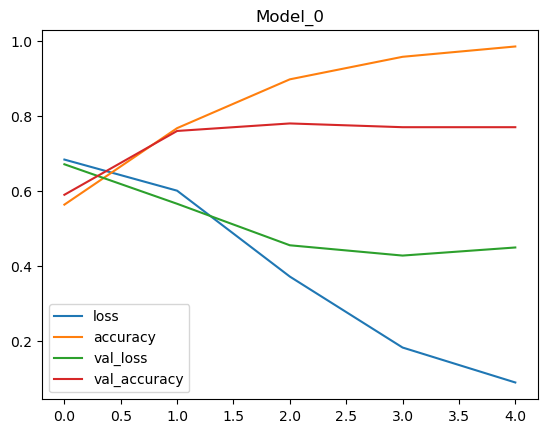

In [34]:
#Let's visualize loss curves during training
pd.DataFrame(model_0_history.history).plot(title='Model_0');

In [35]:
# Lets make some predictions
model_0_pred_probs = model_0.predict(test_dataset) # probabilities
model_0_pred = tf.squeeze(tf.round(model_0_pred_probs)) # labels

7/7 [==============================] - 0s 1ms/step


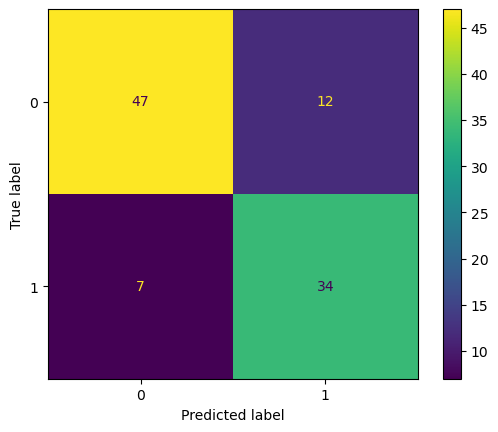

In [36]:
# Visualize a confusion matrix
cm = confusion_matrix(test_labels, model_0_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

### With model0 occured some overffiting, so next experiment it's to reduce this overffiting and improve the results

## Model_1: Same as model_0, but this time with 2 dense layer with less units, dropout layer and using MaxPool1D

In [37]:
# Creation of dense model_1
inputs = layers.Input(shape=(1,), dtype=tf.string)
text_vectorized = text_vectorizer(inputs)
text_embed = embedding(text_vectorized)
x = layers.Dense(36, activation='relu')(text_embed)
x = layers.Dropout(0.5)(x)
x = layers.Dense(36, activation='relu')(x)
x = layers.GlobalMaxPool1D()(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_1 = tf.keras.Model(inputs, outputs)

In [38]:
#Check model_1 summary
model_1.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization (TextVe  (None, 23)                0         
 ctorization)                                                    
                                                                 
 embedding (Embedding)       (None, 23, 128)           1280000   
                                                                 
 dense_2 (Dense)             (None, 23, 36)            4644      
                                                                 
 dropout (Dropout)           (None, 23, 36)            0         
                                                                 
 dense_3 (Dense)             (None, 23, 36)            1332      
                                                           

In [39]:
# Compile the model
model_1.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

In [40]:
# Fit the model
model_1_history = model_1.fit(train_dataset,
                              epochs=5,
                              steps_per_epoch=len(train_dataset),
                              validation_data=val_dataset,
                              validation_steps=len(val_dataset))

Epoch 1/5
50/50 [==============================] - 1s 14ms/step - loss: 0.5438 - accuracy: 0.8313 - val_loss: 0.4879 - val_accuracy: 0.7500
Epoch 2/5
50/50 [==============================] - 1s 12ms/step - loss: 0.2313 - accuracy: 0.9600 - val_loss: 0.4098 - val_accuracy: 0.7900
Epoch 3/5
50/50 [==============================] - 1s 12ms/step - loss: 0.1419 - accuracy: 0.9600 - val_loss: 0.4020 - val_accuracy: 0.8100
Epoch 4/5
50/50 [==============================] - 1s 12ms/step - loss: 0.0833 - accuracy: 0.9787 - val_loss: 0.4415 - val_accuracy: 0.8200
Epoch 5/5
50/50 [==============================] - 1s 12ms/step - loss: 0.0606 - accuracy: 0.9812 - val_loss: 0.4509 - val_accuracy: 0.8400


In [41]:
# Evaluate the model
model_1_results = model_1.evaluate(test_dataset)
model_1_results

7/7 [==============================] - 0s 1ms/step - loss: 0.4163 - accuracy: 0.8200


[0.41625481843948364, 0.8199999928474426]

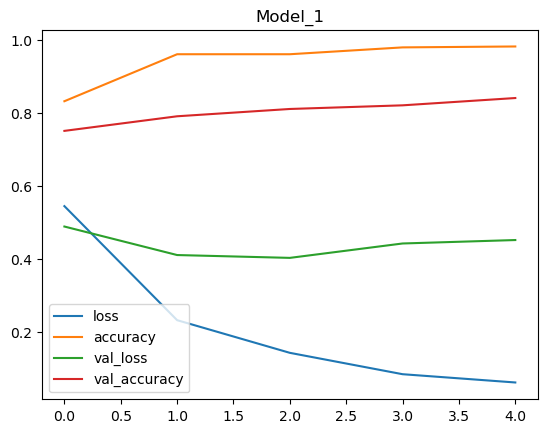

In [89]:
#Let's visualize loss curves during training
pd.DataFrame(model_1_history.history).plot(title='Model_1');

#### We got some better results

In [42]:
#make predictions
model_1_pred_probs = model_1.predict(test_dataset)
model_1_preds = tf.squeeze(tf.round(model_1_pred_probs))

7/7 [==============================] - 0s 1ms/step


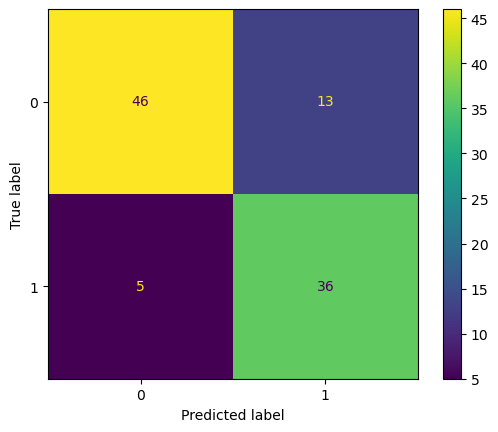

In [43]:
#Visualize a confusion matrix
# Visualize a confusion matrix
cm = confusion_matrix(test_labels, model_1_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

# Model 2: Lets use a pretrained model from TensorFlow Hub

### Using Universal Sentence Encoder

In [44]:

embed = hub.KerasLayer("https://www.kaggle.com/models/google/universal-sentence-encoder/TensorFlow2/universal-sentence-encoder/2",
                       input_shape=[],
                       dtype=tf.string,
                       trainable=False,
                       name='universal_sentence_encoder')

In [45]:
#Using the layer to embed random sample
embed([random_sentence])[0][:100]

<tf.Tensor: shape=(100,), dtype=float32, numpy=
array([ 0.02643066,  0.0239416 , -0.01015753,  0.0085636 ,  0.01048261,
        0.04652534,  0.00923801,  0.00675451,  0.02827949, -0.09432352,
        0.01800776, -0.02466341,  0.03500738,  0.06511964, -0.10471714,
        0.07776266, -0.00699166,  0.02291047,  0.0434807 , -0.01902169,
        0.04238449,  0.00524246, -0.03029945,  0.01109666,  0.01131373,
        0.01638109, -0.07405394, -0.07184456, -0.02049227, -0.06476367,
       -0.00472812, -0.01885919,  0.08763471,  0.02257427,  0.03395183,
       -0.00451435,  0.03590077,  0.02842287, -0.02724211,  0.0768045 ,
        0.04349567, -0.03512977,  0.06687439,  0.04912957, -0.07584704,
       -0.00091417, -0.02987212, -0.00141028,  0.00068082, -0.06821379,
       -0.04375101, -0.07262394,  0.02838601,  0.04158971, -0.06147071,
       -0.00264   , -0.07760028, -0.05007929, -0.01910333, -0.07639879,
        0.03450269, -0.04155753,  0.07891215, -0.05660439, -0.07137529,
        0.061657

In [46]:
#Creation of model2
inputs = layers.Input(shape=[], dtype=tf.string)
x = embed(inputs)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_2 = tf.keras.Model(inputs, outputs)

In [47]:
#compile the model
model_2.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

In [48]:
#See model_2 summary
model_2.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None,)]                 0         
                                                                 
 universal_sentence_encoder  (None, 512)               256797824 
  (KerasLayer)                                                   
                                                                 
 dense_5 (Dense)             (None, 1)                 513       
                                                                 
Total params: 256798337 (979.61 MB)
Trainable params: 513 (2.00 KB)
Non-trainable params: 256797824 (979.61 MB)
_________________________________________________________________


In [49]:
#Fit the model
model_2_history = model_2.fit(train_dataset,
                              epochs=5,
                              steps_per_epoch=len(train_dataset),
                              validation_data=val_dataset,
                              validation_steps=len(val_dataset))

Epoch 1/5
50/50 [==============================] - 2s 10ms/step - loss: 0.6838 - accuracy: 0.6175 - val_loss: 0.6718 - val_accuracy: 0.7700
Epoch 2/5
50/50 [==============================] - 0s 4ms/step - loss: 0.6579 - accuracy: 0.7875 - val_loss: 0.6516 - val_accuracy: 0.7900
Epoch 3/5
50/50 [==============================] - 0s 4ms/step - loss: 0.6344 - accuracy: 0.8400 - val_loss: 0.6326 - val_accuracy: 0.8000
Epoch 4/5
50/50 [==============================] - 0s 4ms/step - loss: 0.6126 - accuracy: 0.8500 - val_loss: 0.6146 - val_accuracy: 0.7900
Epoch 5/5
50/50 [==============================] - 0s 4ms/step - loss: 0.5923 - accuracy: 0.8600 - val_loss: 0.5977 - val_accuracy: 0.8100


In [50]:
# Evaluate the model
model_2_results = model_2.evaluate(test_dataset)
model_2_results

7/7 [==============================] - 0s 4ms/step - loss: 0.6010 - accuracy: 0.8700


[0.6009615659713745, 0.8700000047683716]

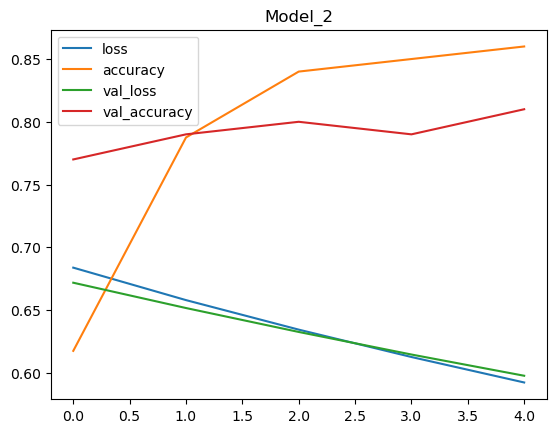

In [92]:
#Let's visualize loss curves during training
pd.DataFrame(model_2_history.history).plot(title='Model_2');

In [68]:
#make predictions
model_2_pred_probs = model_2.predict(test_dataset)
model_2_preds = tf.squeeze(tf.round(model_2_pred_probs))

7/7 [==============================] - 0s 4ms/step


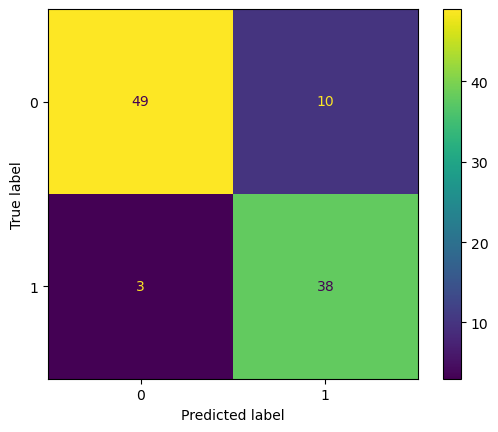

In [69]:
#Visualize a confusion matrix
cm = confusion_matrix(test_labels, model_2_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

### Lets try improve model_2 by adding a dense layer

In [51]:
#Creation of model3
inputs = layers.Input(shape=[], dtype=tf.string)
x = embed(inputs)
x = layers.Dense(16, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)
model_3 = tf.keras.Model(inputs, outputs)

In [52]:
model_3.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None,)]                 0         
                                                                 
 universal_sentence_encoder  (None, 512)               256797824 
  (KerasLayer)                                                   
                                                                 
 dense_6 (Dense)             (None, 16)                8208      
                                                                 
 dense_7 (Dense)             (None, 1)                 17        
                                                                 
Total params: 256806049 (979.64 MB)
Trainable params: 8225 (32.13 KB)
Non-trainable params: 256797824 (979.61 MB)
_________________________________________________________________


In [53]:
#compile the model
model_3.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

In [54]:
#Fit the model
model_3_history = model_3.fit(train_dataset,
                              epochs=5,
                              steps_per_epoch=len(train_dataset),
                              validation_data=val_dataset,
                              validation_steps=len(val_dataset))

Epoch 1/5
50/50 [==============================] - 1s 11ms/step - loss: 0.6570 - accuracy: 0.7425 - val_loss: 0.6077 - val_accuracy: 0.8900
Epoch 2/5
50/50 [==============================] - 0s 4ms/step - loss: 0.5446 - accuracy: 0.8825 - val_loss: 0.4971 - val_accuracy: 0.8400
Epoch 3/5
50/50 [==============================] - 0s 4ms/step - loss: 0.4346 - accuracy: 0.8975 - val_loss: 0.4143 - val_accuracy: 0.8400
Epoch 4/5
50/50 [==============================] - 0s 4ms/step - loss: 0.3552 - accuracy: 0.9062 - val_loss: 0.3613 - val_accuracy: 0.8400
Epoch 5/5
50/50 [==============================] - 0s 4ms/step - loss: 0.3029 - accuracy: 0.9137 - val_loss: 0.3278 - val_accuracy: 0.8300


In [55]:
# Evaluate the model
model_3_results = model_3.evaluate(test_dataset)
model_3_results

7/7 [==============================] - 0s 4ms/step - loss: 0.3029 - accuracy: 0.9500


[0.3028530180454254, 0.949999988079071]

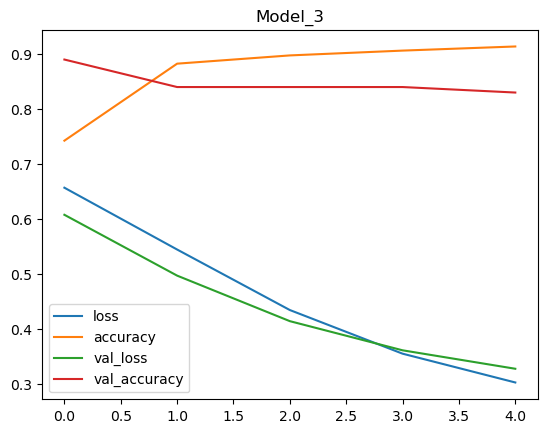

In [90]:
#Let's visualize loss curves during training
pd.DataFrame(model_3_history.history).plot(title='Model_3');

In [56]:
#make predictions
model_3_pred_probs = model_3.predict(test_dataset)
model_3_preds = tf.squeeze(tf.round(model_3_pred_probs))

7/7 [==============================] - 0s 4ms/step


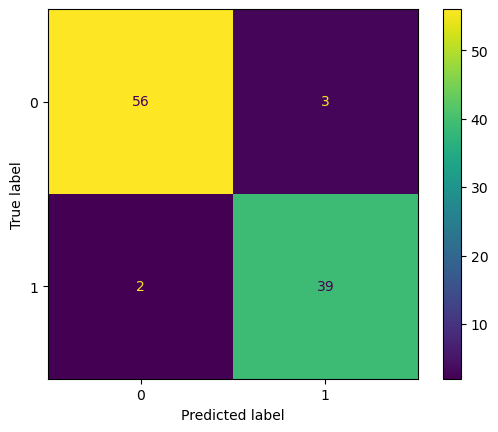

In [57]:
#Visualize a confusion matrix
cm = confusion_matrix(test_labels, model_3_preds)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

# Visualize all models results

In [84]:
model_0_results = evaluate_model(test_labels, model_0_pred)
model_1_results = evaluate_model(test_labels, model_1_preds)
model_2_results = evaluate_model(test_labels, model_2_preds)
model_3_results = evaluate_model(test_labels, model_3_preds)

In [85]:
# Create a DataFrame with all results
all_results = pd.DataFrame({'Model_0':model_0_results,
                            'Model_1':model_1_results,
                            'Model_2':model_2_results,
                            'Model_3':model_3_results})

In [86]:
all_results

,Model_0,Model_1,Model_2,Model_3
Accuracy,0.810000,0.820000,0.870000,0.950000
Precision,0.816562,0.833381,0.880545,0.950369
Recall,0.810000,0.820000,0.870000,0.950000
F1-Score,0.811256,0.821455,0.871013,0.950088


In [87]:
# Tranpose DataFrame
all_results = all_results.transpose()
all_results

,Accuracy,Precision,Recall,F1-Score
Model_0,0.81,0.816562,0.81,0.811256
Model_1,0.82,0.833381,0.82,0.821455
Model_2,0.87,0.880545,0.87,0.871013
Model_3,0.95,0.950369,0.95,0.950088


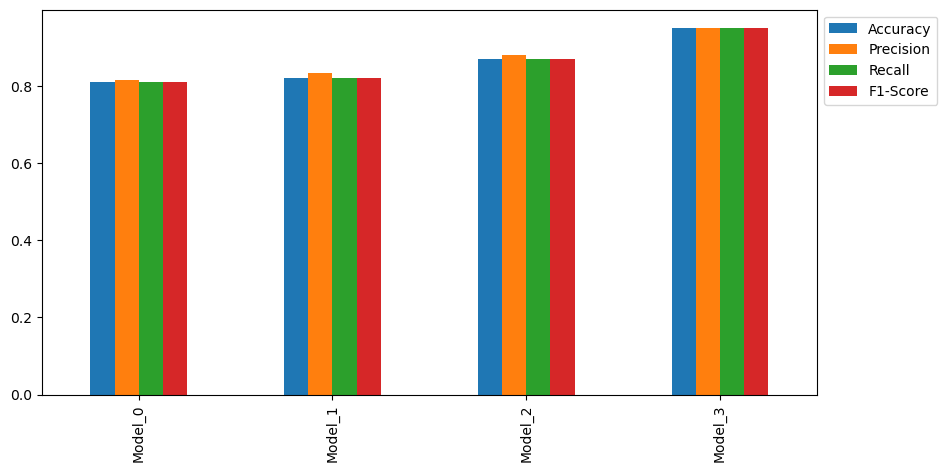

In [94]:
#Plot and compare all of the model results
all_results.plot(kind='bar', figsize=(10,5)).legend(bbox_to_anchor=(1.,1.));